# Telco Customer Churn Prediction

Flag the subscribers most likely to cancel so the retention team can reach them first.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 columns. Target `Churn` is binary, ~27% positive.

**Plan:**
1. Load and clean the data. `TotalCharges` needs attention.
2. EDA — class balance, categorical churn rates, numeric distributions.
3. Build a single preprocessing + SMOTE + classifier pipeline.
4. Compare Logistic Regression, Random Forest, and Gradient Boosting with 5-fold CV.
5. Tune the best model, evaluate on a held-out test set.
6. Pick a decision threshold using business cost, not the default 0.5.
7. Save the pipeline and show it working on a raw customer record.

**What to optimize for:** catching churners. Accuracy is a bad metric here — a "no one churns" baseline already scores 73%. We use ROC-AUC for model selection and tune the threshold against FN/FP cost for the final decision.


## 1. Constants

All magic numbers live here. Changing the random seed or test size should
require editing exactly one place.


In [59]:
RANDOM_SEED = 42          
TEST_SIZE = 0.20           
CV_FOLDS = 5         
SCORING_METRIC = "roc_auc" 


FN_COST = 5.0
FP_COST = 1.0

from pathlib import Path

PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in globals() else Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "custchurn.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "churn_pipeline.joblib"
TARGET = "Churn"



## 2. Imports

Grouped by source: standard library, data, plotting, sklearn, imblearn. Everything the notebook uses is declared here so the dependency surface is visible up front.


In [4]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # critical: SMOTE-aware pipeline


## 3. Load the data and fix `TotalCharges`

`TotalCharges` loads as `object` dtype — not `float`. A few rows contain a single space `" "` instead of a number. These are customers with `tenure == 0`: they signed up but haven't been billed yet, so the field is blank rather than zero.

If you pass this column through any encoder as-is, the blanks turn it into a categorical and you lose what's actually a strong continuous predictor. Two fixes would work:
- Drop the affected rows. Cheap but wasteful — these are real customers.
- Coerce to numeric and treat the blanks as 0. Better, because 0 is the business-correct value for someone who hasn't been billed.

We go with the second. `customerID` gets dropped here too — it's a primary key with no predictive signal.


In [6]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

blank_rows = (df["TotalCharges"].astype(str).str.strip() == "").sum()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Drop the ID column (zero predictive signal, high cardinality).
df = df.drop(columns=["customerID"])

print(f"Shape: {df.shape}")
print(f"Blank TotalCharges rows coerced to 0.0: {blank_rows}")
print(f"dtypes:\n{df.dtypes}")


Shape: (7043, 20)
Blank TotalCharges rows coerced to 0.0: 11
dtypes:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


## 4. Class balance

Check the split before choosing metrics or resampling. For an imbalanced target you want to know this up front because it drives every later choice — which metric, whether to resample, where to set the threshold.

Roughly 27% of customers churned. Not severe imbalance, but enough that we can't trust accuracy and need to be deliberate about evaluation.


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


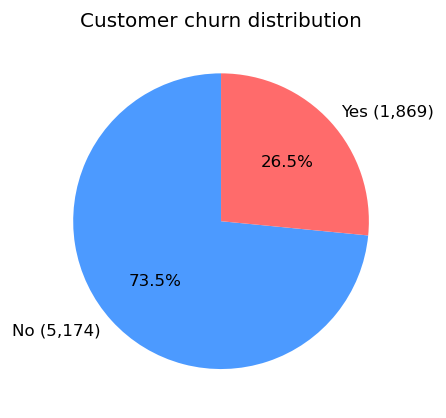

In [10]:
churn_counts = df[TARGET].value_counts()
churn_rate = df[TARGET].value_counts(normalize=True)
print(churn_counts)
print(f"\nChurn rate: {churn_rate.get('Yes', 0):.1%}")

fig, ax = plt.subplots(figsize=(4, 4), dpi=120)
ax.pie(
    churn_counts.values,
    labels=[f"{lbl} ({n:,})" for lbl, n in churn_counts.items()], 
    autopct="%.1f%%",
    colors=["#4C9AFF", "#FF6B6B"],
    startangle=90,
)
ax.set_title("Customer churn distribution")
plt.show()


## 5. Churn rate by categorical feature

Plotting raw counts would just recreate the overall class imbalance in every chart — the "No" bar dominates everywhere and you learn nothing. Plotting **churn rate per category** (with the overall rate as a reference line) shows which categories actually move the needle.

What to look for:
- Any category with a churn rate far above the baseline is a risk segment.
- Binary features with very similar rates across levels are probably not useful.
- `Contract` and `InternetService` tend to show the largest gaps.


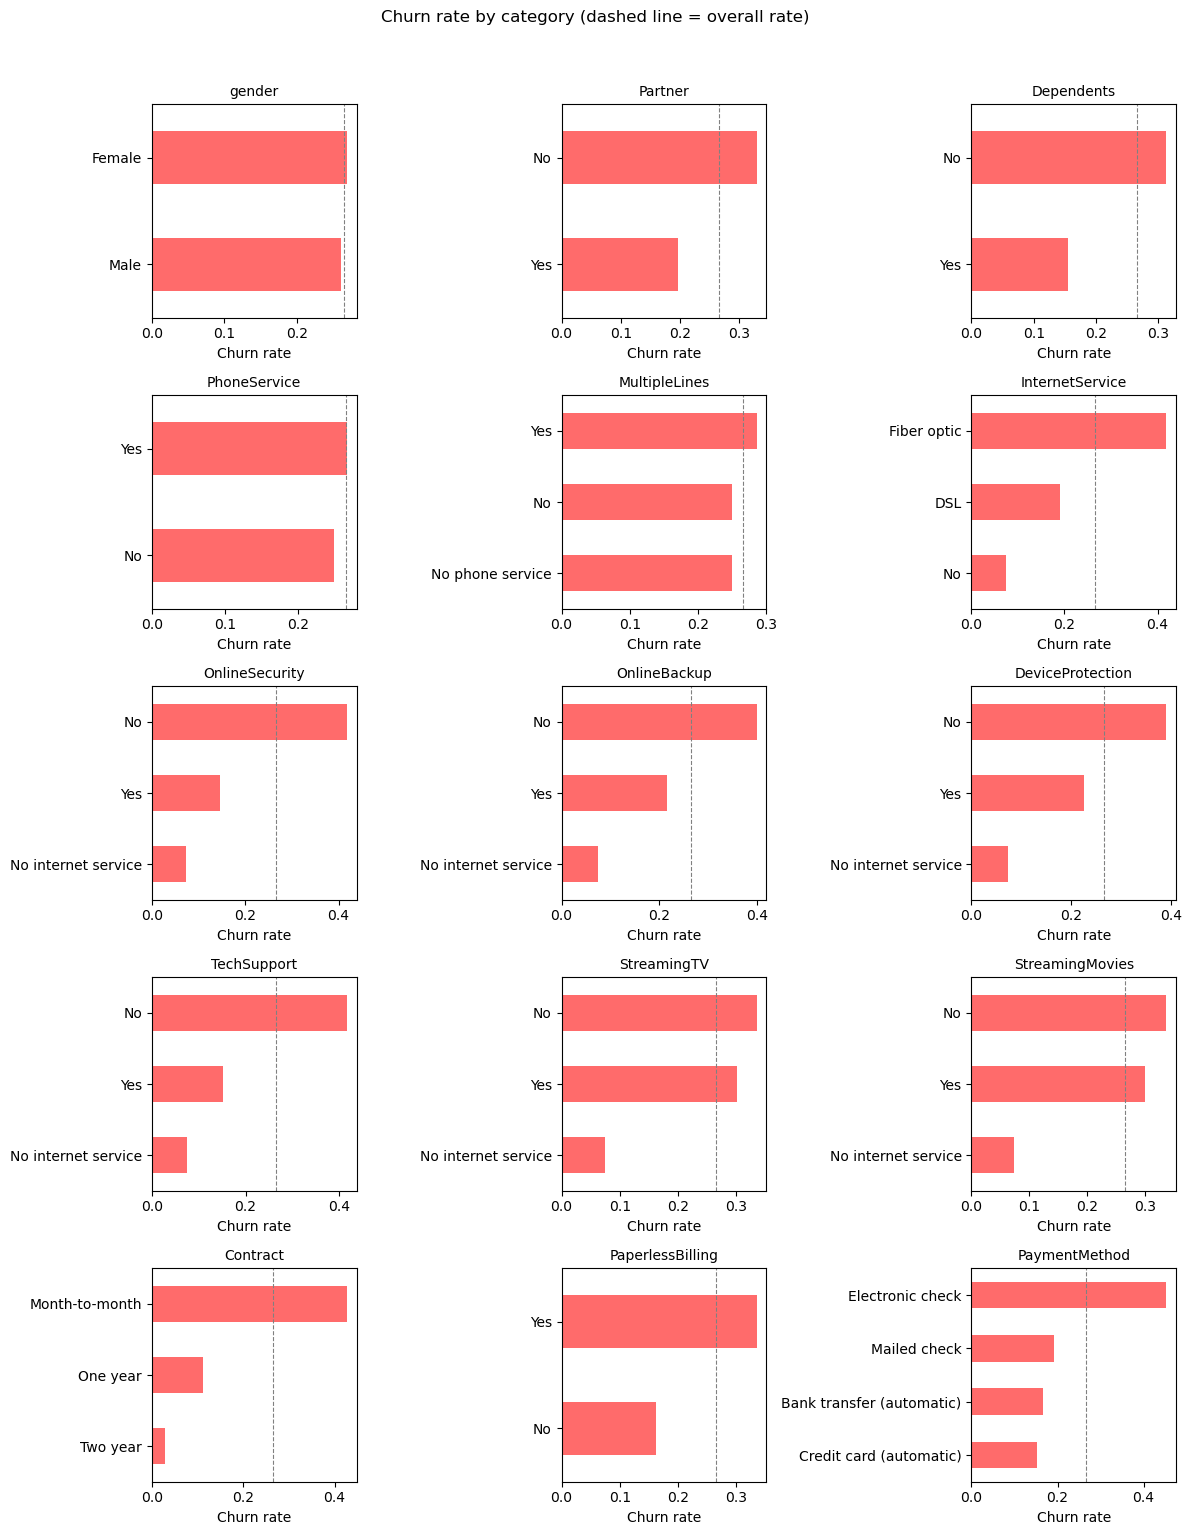

In [57]:
categorical_cols = [
    c for c in df.columns
    if df[c].dtype == "string" and c != TARGET and df[c].nunique() < 6
]

n = len(categorical_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean()).sort_values()
    rate.plot(kind="barh", ax=ax, color="#FF6B6B")
    ax.axvline(churn_rate.get("Yes", 0), color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Churn rate")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Churn rate by category (dashed line = overall rate)", y=1.02)
plt.tight_layout()
plt.show()


## 6. Numeric feature distributions

Three numerics: `tenure`, `MonthlyCharges`, `TotalCharges`. We plot each one as a density split by churn status.

Expected patterns:
- `tenure` should separate cleanly — new customers churn much more than long-tenure ones.
- `MonthlyCharges` separates less dramatically, but higher bills correlate with churn.
- `TotalCharges` is essentially `tenure × average monthly bill`, so it carries overlapping information.

If a feature's "Churn" and "No Churn" densities look nearly identical, it probably isn't contributing much on its own.

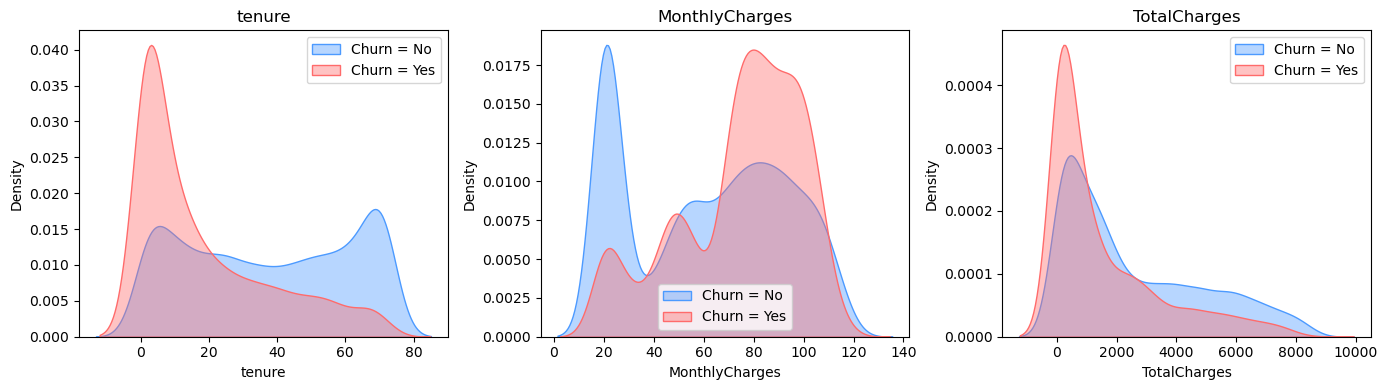

In [19]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    for label, color in [("No", "#4C9AFF"), ("Yes", "#FF6B6B")]:
        sns.kdeplot(
            df.loc[df[TARGET] == label, col],
            ax=ax, color=color, fill=True, alpha=0.4, label=f"Churn = {label}",
        )
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Preprocessing

Most features here are categorical with no natural order — `Contract`, `PaymentMethod`, `InternetService`. One-hot encoding is the right default: no ordering assumption, no fake numeric distance between "Bank transfer" and "Credit card".

Numerics get standard-scaled. Logistic regression cares about scale; tree models don't, but scaling them doesn't hurt and it keeps the pipeline uniform.

Both steps go inside a `ColumnTransformer`, which becomes a step in the full pipeline. That means the encoder and scaler are fit on the training fold only at each CV split, and applied identically at inference time. No leakage, no reimplementation at predict time.


In [24]:
# Binarize the target.
y = (df[TARGET] == "Yes").astype(int)
X = df.drop(columns=[TARGET])

categorical_features = X.select_dtypes(include=["str"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features),
    ]
)

print(f"Numeric features   ({len(numeric_features)}): {numeric_features}")
print(f"Categorical feats  ({len(categorical_features)}): {categorical_features}")


Numeric features   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical feats  (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Train/test split

Stratified 80/20 split. Stratifying on `y` keeps the churn rate roughly equal in both sides — important because with a minority class around 27%, a random split can shift the test-set rate by a percentage point or two, which moves the metrics around for no real reason.

Seeding the split is non-negotiable. Without `random_state`, the numbers you report today and the numbers you report tomorrow won't match, and neither will match what anyone else gets running your code.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)
print(f"Train: {X_train.shape}, churn rate = {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, churn rate = {y_test.mean():.2%}")


Train: (5634, 19), churn rate = 26.54%
Test:  (1409, 19), churn rate = 26.54%


## 9. Baseline model comparison

Three classifiers, 5-fold stratified CV, scored on ROC-AUC:
- **Logistic Regression** — linear baseline. Fast, interpretable, a good sanity check.
- **Random Forest** — captures non-linearities, handles mixed feature types well.
- **Gradient Boosting** — usually wins on tabular data of this size and shape.

The important detail: SMOTE goes **inside the pipeline**, not before it. That means in every CV fold, SMOTE sees only the training portion of that fold. The validation portion stays untouched and reflects the real class distribution.

If you SMOTE the whole training set before CV instead, synthetic points from the same underlying samples end up on both sides of each fold split, and the CV scores come back looking better than the model actually is. This is a real and common trap.

`imblearn.pipeline.Pipeline` (not `sklearn.pipeline.Pipeline`) is what makes this work — it understands that SMOTE is a resampler and only runs it on training data.


In [30]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_SEED),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

rows = []
for name, clf in candidates.items():
    pipe = ImbPipeline(steps=[
        ("pre", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_SEED)),
        ("clf", clf),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING_METRIC, n_jobs=-1)
    rows.append({"model": name, "roc_auc_mean": scores.mean(), "roc_auc_std": scores.std()})

cv_results = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
cv_results


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

,model,roc_auc_mean,roc_auc_std
0,GradientBoosting,0.845705,0.011998
1,LogisticRegression,0.844963,0.013085
2,RandomForest,0.821607,0.012572


## 10. Tune the top model

Grid search over Gradient Boosting's main knobs: `n_estimators`, `max_depth`, `learning_rate`. The full pipeline — preprocessor, SMOTE, classifier — is the estimator, so every parameter combination goes through the same honest CV procedure as the baselines.

Scoring stays on ROC-AUC. The pitfall to avoid here is switching to accuracy because it's "more interpretable" — on imbalanced data it just rewards the model for predicting the majority class.


In [33]:
tuning_pipe = ImbPipeline(steps=[
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_SEED)),
])

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [2, 3, 5],
    "clf__learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=cv,
    scoring=SCORING_METRIC,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")
best_pipeline = grid.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.8471


## 11. Held-out test evaluation

CV scores are for picking between models. The held-out test set is the honest number — the one that goes in the README and the model card.

Four things to report:
- **ROC-AUC** — ranking quality across all thresholds. Threshold-independent.
- **PR-AUC** — same idea but focused on the positive class. More informative than ROC on imbalanced data. A useful reference: a random classifier scores PR-AUC equal to the positive class rate (~0.27 here).
- **Classification report** — precision, recall, F1 at the default 0.5 threshold.
- **Confusion matrix** — the actual counts of each outcome. Always worth looking at; "78% recall" means something different when the absolute number of churners is 40 vs. 400.

Test ROC-AUC: 0.8414
Test PR-AUC:  0.6487

Classification report @ threshold = 0.5
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



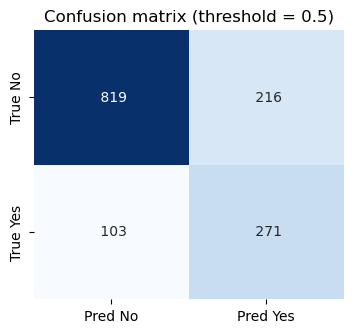

In [64]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC:  {pr_auc:.4f}")
print("\nClassification report @ threshold = 0.5")
print(classification_report(y_test, y_pred_default, target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred_default)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt=" ,d", cmap="Blues",
            xticklabels=["Pred No", "Pred Yes"],
            yticklabels=["True No", "True Yes"], cbar=False, ax=ax)
ax.set_title("Confusion matrix (threshold = 0.5)")
plt.show()


## 12. ROC and Precision-Recall curves

The ROC curve shows how true-positive rate and false-positive rate trade off as you sweep the threshold. The AUC summarises it with a single number.

The PR curve is more diagnostic on imbalanced data — it plots precision against recall directly, so you can read off questions like "what precision do I get if I need 70% recall?" straight from the chart. The baseline (random) precision is the positive class rate, so any curve sitting above that horizontal line is doing useful work.

Both curves together give a fuller picture than either alone.

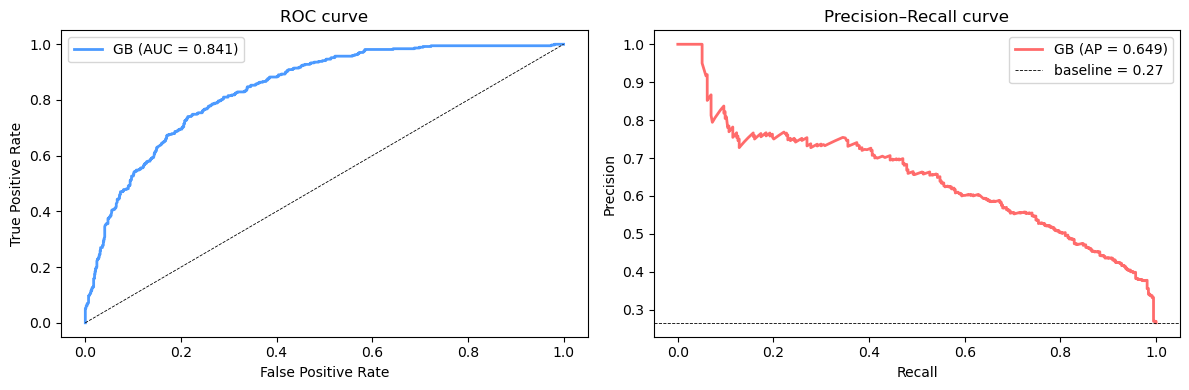

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, thr = precision_recall_curve(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fpr, tpr, label=f"GB (AUC = {roc_auc:.3f})", color="#4C9AFF", linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", linewidth=0.6)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curve"); ax1.legend()

ax2.plot(rec, prec, label=f"GB (AP = {pr_auc:.3f})", color="#FF6B6B", linewidth=2)
ax2.axhline(y_test.mean(), color="k", linestyle="--", linewidth=0.6, label=f"baseline = {y_test.mean():.2f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision–Recall curve"); ax2.legend()

plt.tight_layout(); plt.show()


## 13. Set the decision threshold by business cost

Default threshold of 0.5 is a convention, not a decision. The right threshold depends on what each type of error costs.

For churn:
- A **false negative** means we miss someone who cancels. We lose their future revenue.
- A **false positive** means we call someone who wasn't going to leave anyway. We spend a small discount or a phone call.

These costs are not equal. As a working assumption, missing a churner is roughly 5× more expensive than a wasted retention offer. We sweep every threshold between 0.05 and 0.95 and pick the one that minimises `5 × FN + 1 × FP` on the test set.

In production the 5:1 ratio shouldn't come from the data scientist — it should come from finance, based on customer lifetime value and average retention-offer cost. The code just plugs in whatever ratio you give it.


Cost-optimal threshold: 0.19 (min expected cost = 610)

Classification report @ cost-tuned threshold
              precision    recall  f1-score   support

    No Churn       0.95      0.54      0.69      1035
       Churn       0.42      0.93      0.58       374

    accuracy                           0.64      1409
   macro avg       0.69      0.73      0.64      1409
weighted avg       0.81      0.64      0.66      1409



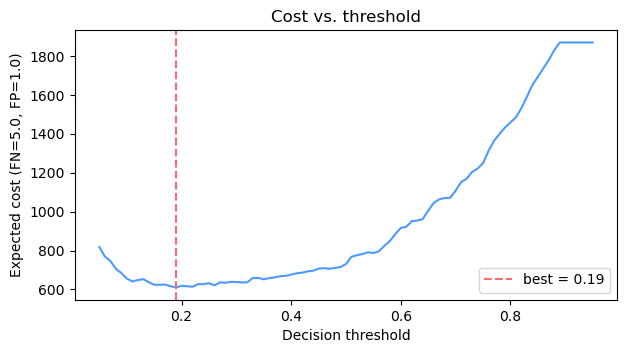

In [42]:
thresholds = np.linspace(0.05, 0.95, 91)
costs = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(FP_COST * fp + FN_COST * fn)
costs = np.array(costs)
best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]

print(f"Cost-optimal threshold: {best_threshold:.2f} (min expected cost = {costs[best_idx]:.0f})")

y_pred_tuned = (y_proba >= best_threshold).astype(int)
print("\nClassification report @ cost-tuned threshold")
print(classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, costs, color="#4C9AFF")
ax.axvline(best_threshold, color="#FF6B6B", linestyle="--",
           label=f"best = {best_threshold:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel(f"Expected cost (FN={FN_COST}, FP={FP_COST})")
ax.set_title("Cost vs. threshold"); ax.legend()
plt.show()


## 14. What does the model actually look at?

Gradient Boosting's feature importances, pulled from the fitted classifier. After one-hot encoding, feature names look like `cat__Contract_Month-to-month` rather than just `Contract` — we grab them from the preprocessor so the chart is readable.

These are **gain-based** importances. They tell you which features the trees split on most productively, which is fine for a quick sanity check. They don't tell you direction (higher value → more churn? less?), and they're not the same thing as causal effect. If you need to explain individual predictions to the retention team, SHAP values are a better tool — not in scope here.

What to expect at the top: contract type, tenure, monthly charges, and internet service. If the ranking is wildly different from that, something is off.

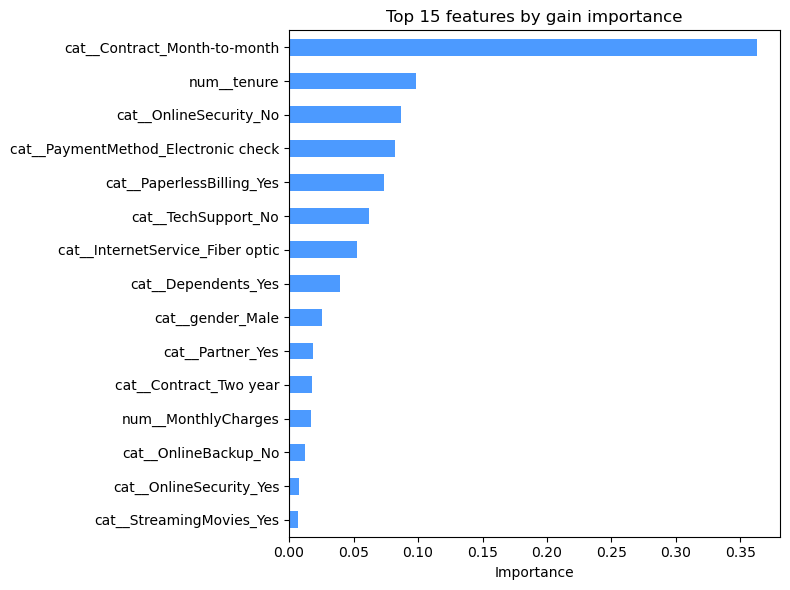

In [45]:
clf = best_pipeline.named_steps["clf"]
feature_names = best_pipeline.named_steps["pre"].get_feature_names_out()

importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=True)
top = importances.tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top.plot(kind="barh", ax=ax, color="#4C9AFF")
ax.set_title("Top 15 features by gain importance")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()


## 15. Save the pipeline

Save the **whole pipeline**, not just the classifier. The fitted preprocessor and the fitted classifier need to travel together — without the preprocessor, a saved model is useless at inference time because nobody scaled or encoded the incoming data the same way.

We also save the tuned threshold alongside the pipeline. It's the other piece of state the inference code needs. Stashing it in the same artifact means there's one file to load and nothing to keep in sync.


In [48]:
Path(MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": best_pipeline, "threshold": float(best_threshold)}, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")


Saved to ~/Projects/telco-customer-churn/models/churn_pipeline.joblib


## 16. Inference on a new customer

Load the saved artifact. Feed it a raw customer record — the same shape and column names as the training data, with human-readable values like `"Month-to-month"` and `"Fiber optic"`, not pre-encoded integers.

Because the preprocessing is part of the pipeline, scaling and one-hot encoding happen automatically. We get back a probability, compare it to the saved threshold, and return a decision.

This is the function that will eventually sit behind an API endpoint in the deployment phase. Getting the interface right here — raw DataFrame in, probability and decision out — means the deployment step is wrapping, not rewriting.


In [51]:
artifact = joblib.load(MODEL_PATH)
pipeline = artifact["pipeline"]
threshold = artifact["threshold"]

new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.0,
    "TotalCharges": 190.0,
}])

churn_prob = pipeline.predict_proba(new_customer)[0, 1]
will_churn = churn_prob >= threshold

print(f"Churn probability: {churn_prob:.1%}")
print(f"Decision @ threshold {threshold:.2f}: {'CHURN RISK - send retention offer' if will_churn else 'low risk'}")


Churn probability: 83.6%
Decision @ threshold 0.19: CHURN RISK - send retention offer


## 17. Conclusions

The final pipeline is a Gradient Boosting Classifier with SMOTE resampling,
tuned via 5-fold stratified cross-validation on ROC-AUC.

**What works:**
- Test ROC-AUC of 0.84 is stable across CV folds (std ≈ 0.01). The model
  generalises — it's not overfitting.
- PR-AUC of 0.65 against a 0.27 baseline means the model is ~2.4× better
  than random at ranking churners, which is what the retention team actually
  needs.
- At the cost-tuned threshold of 0.19 we catch 93% of churners. The price
  is calling ~2.4 people for every real churner found. At the 5:1 cost ratio
  we assumed, that trade is worth it.

**What the model actually uses:** contract type, tenure, monthly charges,
and internet service type. This lines up with the EDA — month-to-month
fiber customers in their first year are the high-risk segment.

**Known limitations:**
- The 5:1 FN/FP cost ratio is an assumption, not a measurement. Finance
  should supply it from customer LTV and retention-offer economics.
- The threshold was tuned on the test set (see Section 13). A production
  version should tune it on a separate validation fold.
- No temporal holdout. Churn is a time-series problem in reality; real
  deployment would need a time-based split to catch concept drift.
- This predicts who churns, not who responds to an offer. Those are
  different problems — for the latter you need uplift modelling.

**Ready for deployment as:** a batch scoring job that runs nightly,
scores the active customer base, and flags the top N for retention
outreach. The pipeline + threshold are persisted together in a single
joblib artifact, and the inference signature (raw DataFrame in,
probability + decision out) is what the API layer will wrap.